mean_squre_error value : 20921337.735248428
r^2 value of model : 0.8652398796807108


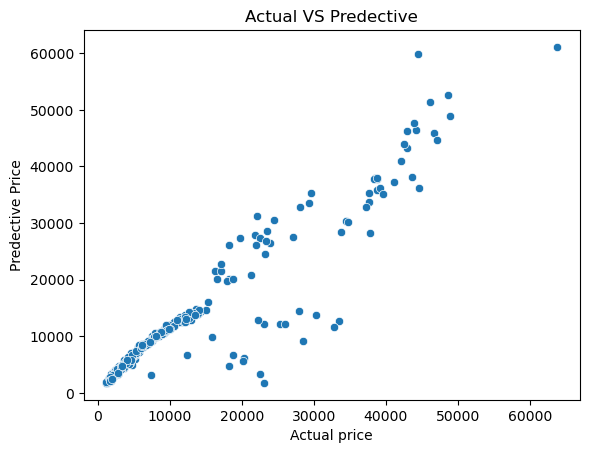

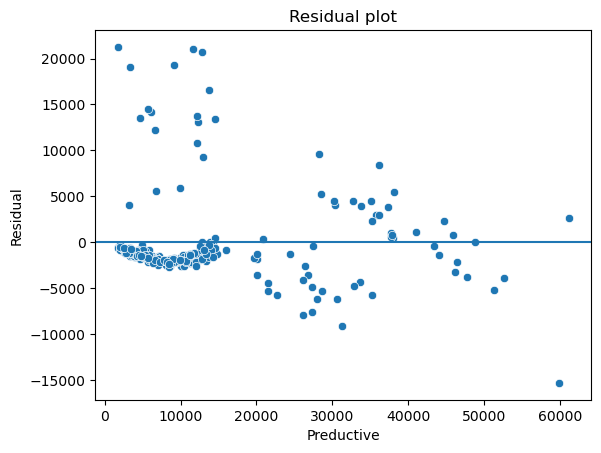

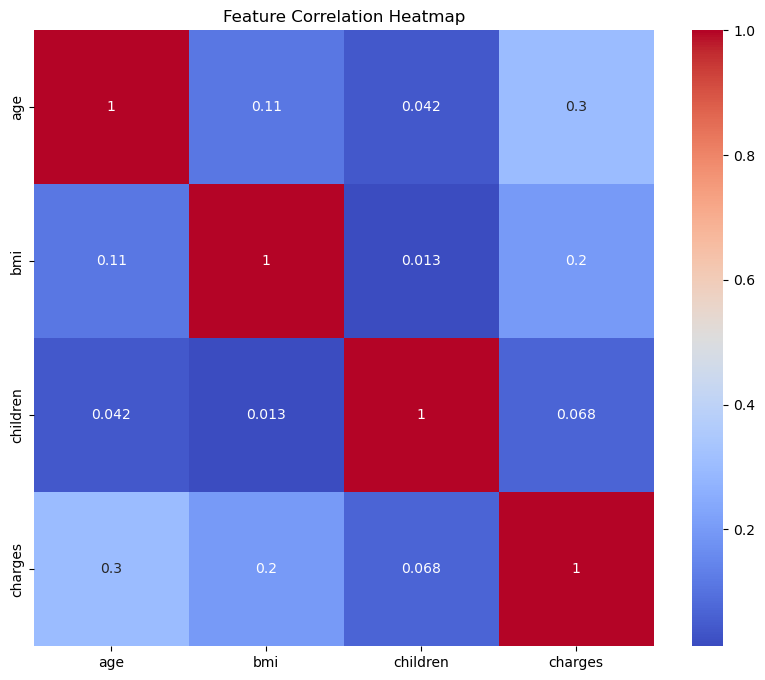

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score ,mean_squared_error

df1=pd.read_csv("insurance.csv").copy()
df=df1.copy()

X = df.drop(columns=["charges"],axis=1)
Y = df["charges"]

X = pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)

X["sex"] = X["sex"].map({"female" : 0 , "male" : 1})
X["smoker"] = X["smoker"].map({"no" : 0 , "yes" : 1})

# add new columns for more acuurecy

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]
X["children_smoker"] = X["children"] * X["smoker"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state=42,test_size=0.2)

model = LinearRegression()
model.fit(x_train,y_train)

predict_data_by_model=model.predict(x_test)

r2_value = r2_score(y_test, predict_data_by_model)
mse_value = mean_squared_error(y_test, predict_data_by_model)

print(f"mean_squre_error value : {mse_value}")
print(f"r^2 value of model : {r2_value}")

sns.scatterplot(x = y_test , y = predict_data_by_model)
plt.xlabel("Actual price")
plt.ylabel("Predective Price")
plt.title("Actual VS Predective")
plt.show()

residual = y_test - predict_data_by_model
sns.scatterplot(x = predict_data_by_model , y = residual)
plt.axhline(0)
plt.xlabel("Preductive")
plt.ylabel("Residual")
plt.title("Residual plot")
plt.show()

df_numeric = df.select_dtypes(include = ['number'])
plt.figure(figsize = (10,8))
sns.heatmap(df_numeric.corr(),annot = True,cmap = "coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [81]:
print(f"New Data :")
X

New Data :


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker,children_smoker
0,19,0,27.900,0,1,0,0,1,19,27.90,0
1,18,1,33.770,1,0,0,1,0,0,0.00,0
2,28,1,33.000,3,0,0,1,0,0,0.00,0
3,33,1,22.705,0,0,1,0,0,0,0.00,0
4,32,1,28.880,0,0,1,0,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,0,0,0,0.00,0
1334,18,0,31.920,0,0,0,0,0,0,0.00,0
1335,18,0,36.850,0,0,0,1,0,0,0.00,0
1336,21,0,25.800,0,0,0,0,1,0,0.00,0


In [82]:
print("Old Data : ")
df1

Old Data : 


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
